# pipekit-train — Bayesian inference (2/3): NumPyro **MCMC / NUTS**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pipekit/blob/main/docs/notebooks/pipekit_train_numpyro_mcmc.ipynb)

Second of three examples (see notebook 1 for `numpyro-svi`). Here we fit the
**same** Bayesian linear-regression model with **MCMC** — the No-U-Turn
Sampler (NUTS). Where SVI *approximates* the posterior with a parametric
guide, MCMC draws **asymptotically exact** samples from it: it is the
*oracle*, at higher cost.

| # | Notebook | Backend | Paradigm |
|---|----------|---------|----------|
| 1 | `pipekit_train_numpyro_svi` | `numpyro-svi` | variational |
| **2** | **this one** | `numpyro-mcmc` | **sampling** — NUTS (one blocking run) |
| 3 | `pipekit_train_blackjax` | `blackjax` | sampling — NUTS via a sampler library |

**The headline:** the `NumpyroTask` is *identical* to notebook 1's — only
the `backend` string changes. SVI and MCMC are two engines for one model.
See [`numpyro_adapter.md`](../design-train/numpyro_adapter.md) (ADR **D13**).

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pipekit-train[numpyro] @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit-train",
            "pipekit @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit",
        ],
        check=True,
    )

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from pipekit import Identity
from pipekit_train import IterableDataset, TrainingLoop
from pipekit_train.adapters.bayes import NumpyroTask

/home/user/pipekit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Reproducibility readout — version metadata for the committed outputs.
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,jax,numpyro,pipekit,pipekit_train",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

numpy        : 2.4.4
jax          : 0.10.1
numpyro      : 0.21.0
pipekit      : 0.0.1
pipekit_train: 0.0.1

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.5
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. The problem & model

Identical to notebook 1: priors $w \sim \mathcal{N}(0,5)$, $b \sim
\mathcal{N}(0,5)$, $\sigma \sim \mathrm{HalfNormal}(1)$, Gaussian likelihood
$y_i \sim \mathcal{N}(w x_i + b, \sigma^2)$, data drawn from $y = 2x + 1$.

In [4]:
rng = np.random.default_rng(0)
n = 128
xs = rng.uniform(-1.0, 1.0, size=(n, 1)).astype(np.float32)
ys = (2.0 * xs[:, 0] + 1.0 + 0.1 * rng.standard_normal(n)).astype(np.float32)

pairs = list(zip(xs, ys, strict=True))
dataset = IterableDataset(source=pairs, content_hash=f"linreg-{n}")


def model(x, y=None):
    w = numpyro.sample("w", dist.Normal(0.0, 5.0))
    b = numpyro.sample("b", dist.Normal(0.0, 5.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = w * x[..., 0] + b
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

## 2. The inference method — NUTS

The No-U-Turn Sampler (Hoffman & Gelman, 2014) is **adaptive Hamiltonian
Monte Carlo**. It augments the parameters $\theta$ with a momentum
$p \sim \mathcal{N}(0, M)$ and simulates Hamiltonian dynamics on

$$
H(\theta, p) = -\log p(\theta \mid \mathbf{x}, \mathbf{y}) + \tfrac{1}{2}\, p^\top M^{-1} p,
$$

using gradients of the log-posterior; NUTS picks each trajectory length
automatically (no U-turns). A **warmup** phase adapts the leapfrog step size
(dual averaging) and the mass matrix $M$. The result is a set of correlated
draws $\{\theta^{(s)}\}_{s=1}^{S} \sim p(\theta \mid \mathbf{x}, \mathbf{y})$.

Crucially this is **not** a per-gradient-step optimiser: it is a *single
blocking run* of `warmup + sampling` over the full likelihood — so unlike
SVI, `optimizer_config` / `max_steps` / per-step eval do **not** apply. The
`numpyro-mcmc` backend fires only `on_train_begin` / `on_train_end`.

## 3. Fit through the `TrainingLoop`

The `NumpyroTask` is the **same kind of object as notebook 1** — here we set
the MCMC controls (`num_warmup`, `num_samples`). The backend materialises
the full dataset into single `(X, y)` arrays and calls `mcmc.run` once.

In [5]:
task = NumpyroTask(
    model,
    predictive_site="obs",
    num_warmup=500,
    num_samples=500,
)

loop = TrainingLoop(
    model_op=Identity(),  # ignored; the task carries the model
    dataset=dataset,
    backend="numpyro-mcmc",
    task=task,
    seed=0,
)

In [6]:
oracle_op, artifact = loop.run()

info = artifact.backend_info
print(f"Backend        : {info['backend']}")
print(f"Warmup / draws : {info['num_warmup']} / {info['num_samples']}")
print(f"Chains         : {info['num_chains']}")
print(f"Divergences    : {info['num_divergences']}")
print(f"Sampled sites  : {info['sites']}")

Backend        : numpyro-mcmc
Warmup / draws : 500 / 500
Chains         : 1
Divergences    : 0
Sampled sites  : ['b', 'sigma', 'w']


**Divergences** are NUTS's built-in health check: a divergent transition
signals the sampler failed to integrate the dynamics (often a too-tight
posterior geometry). Zero (or very few) divergences over the run is the
green light here.

## 4. The full posterior

Because MCMC samples the parameters *directly*, `oracle_op.posterior` is a
dict of draws $\{w^{(s)}, b^{(s)}, \sigma^{(s)}\}$ — the full posterior that
SVI only approximated with a Gaussian. We plot the marginal histograms
against the truth $w=2$, $b=1$.

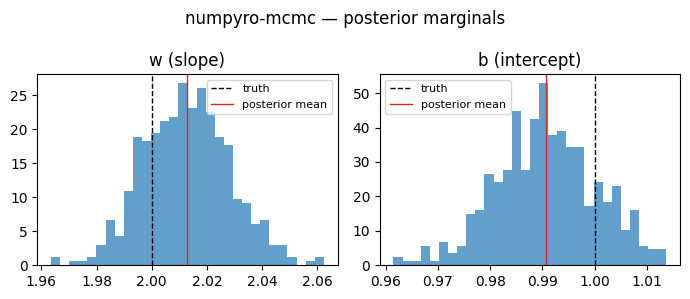

w: 2.013 ± 0.016   (truth 2.0)
b: 0.991 ± 0.010   (truth 1.0)


In [7]:
post = oracle_op.posterior
w_s = np.asarray(post["w"])
b_s = np.asarray(post["b"])

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, samples, truth, name in (
    (axes[0], w_s, 2.0, "w (slope)"),
    (axes[1], b_s, 1.0, "b (intercept)"),
):
    ax.hist(samples, bins=30, color="C0", alpha=0.7, density=True)
    ax.axvline(truth, color="k", ls="--", lw=1, label="truth")
    ax.axvline(samples.mean(), color="C3", lw=1, label="posterior mean")
    ax.set_title(name)
    ax.legend(fontsize=8)
fig.suptitle("numpyro-mcmc — posterior marginals")
fig.tight_layout()
plt.show()

print(f"w: {w_s.mean():.3f} ± {w_s.std():.3f}   (truth 2.0)")
print(f"b: {b_s.mean():.3f} ± {b_s.std():.3f}   (truth 1.0)")

## 5. Posterior predictive

As in notebook 1, the trained `Operator` returns the posterior-predictive
mean of the `obs` site, marginalised over the posterior draws:

$$
p(y^\ast \mid x^\ast, \text{data}) \approx \frac{1}{S}\sum_{s=1}^{S}
p\!\bigl(y^\ast \mid x^\ast, \theta^{(s)}\bigr).
$$

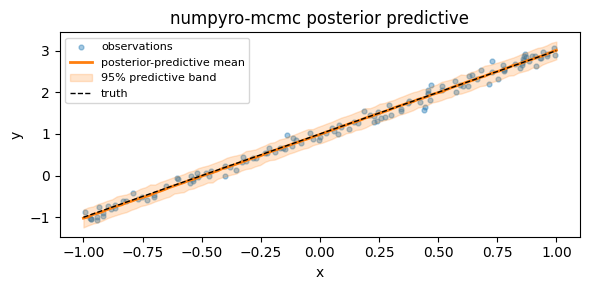

In [8]:
x_grid = jnp.linspace(-1.0, 1.0, 100).reshape(-1, 1)
y_mean = np.asarray(oracle_op(x_grid))
draws = oracle_op.predictive(jax.random.key(1), x_grid)["obs"]
lo, hi = np.percentile(np.asarray(draws), [2.5, 97.5], axis=0)

plt.figure(figsize=(6, 3))
plt.scatter(xs[:, 0], ys, s=12, alpha=0.4, label="observations")
plt.plot(x_grid[:, 0], y_mean, "C1", lw=2, label="posterior-predictive mean")
plt.fill_between(
    x_grid[:, 0], lo, hi, color="C1", alpha=0.2, label="95% predictive band"
)
plt.plot([-1, 1], [-1, 3], "k--", lw=1, label="truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=8)
plt.title("numpyro-mcmc posterior predictive")
plt.tight_layout()
plt.show()

## 6. The artifact

The weight blob is the **posterior-samples PyTree** (`oracle_op.posterior`);
it persists through `serialize_weights()` for the model registry, just like
the variational params in notebook 1.

In [9]:
sites = {k: tuple(np.shape(v)) for k, v in oracle_op.posterior.items()}
print("Posterior sites:", sites)
print("Weight-blob bytes:", len(oracle_op.serialize_weights()))

# Both the experiment-backed and the local fallback artifact are dataclasses,
# so `dataclasses.asdict` serialises either; `pipekit-train[experiment]` adds
# native `artifact.save(...)` + model-registry integration on top.
import dataclasses
import json


with open("mcmc_artifact.json", "w") as f:
    json.dump(dataclasses.asdict(artifact), f, indent=2, default=str)
print("Saved mcmc_artifact.json — the run is reproducible.")

Posterior sites: {'b': (500,), 'sigma': (500,), 'w': (500,)}
Weight-blob bytes: 6188
Saved mcmc_artifact.json — the run is reproducible.


### What's next

- **Notebook 3 — `blackjax`**: sample the *same NumPyro model* with a
  *different engine* — BlackJAX's NUTS — via the shared `bayes` bridge.
  "Same model, flip the engine" extends one step further, to a separate
  sampler library.

In [10]:
# Clean up the demo file.
import os


if os.path.exists("mcmc_artifact.json"):
    os.remove("mcmc_artifact.json")